# OSCAR Baseline Workflow (NICO++)

This notebook implements our baseline an OSCAR-style pipeline on NICO++: We implement a topk sparse vectors compression on this, instead of normal OSCAR model which forwards all clip/blip encodings. We only share the topk encodings. Tihs allows further reduction in communication cost. We ran several ablations using this notebook with different values of k. The resulting models are attached in the submission. Final graph provides summary of acc vs k graph. 

## 1) Environment Setup

The next cells install required libraries, load the Hugging Face token from Kaggle secrets, configure logging, import dependencies, and initialize device settings.

In [ ]:
!pip install -q "accelerate>=1.6.0" "transformers>=4.51.0"

In [ ]:
!pip -q install safetensors
!pip install -q "transformers==4.45.2" "accelerate==0.34.2"
!pip install -q "diffusers==0.29.2"
!pip install torch torchvision torchaudio

from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("HF_TOKEN")


import os
import json
import math
import random
import shutil
import warnings
from collections import defaultdict, Counter
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, ConcatDataset

import torchvision
import torchvision.transforms as T
from torchvision.models import resnet18, ResNet18_Weights



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



warnings.filterwarnings("ignore")

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import datetime

import transformers as _tr, diffusers as _df, logging as _pylog
_tr.logging.set_verbosity_error()
_df.logging.set_verbosity_error()
_pylog.getLogger("diffusers").setLevel(_pylog.ERROR)
_pylog.getLogger("transformers").setLevel(_pylog.ERROR)


In [ ]:
SEED = 28
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE  = torch.float16 if DEVICE == "cuda" else torch.float32

NUM_GPUS = torch.cuda.device_count()
GPU0 = torch.device("cuda:0") if NUM_GPUS >= 1 else torch.device("cpu")
GPU1 = torch.device("cuda:1") if NUM_GPUS >= 2 else GPU0

print("Device:", DEVICE)
print(f"GPUs available: {NUM_GPUS}")
for i in range(NUM_GPUS):
    props = torch.cuda.get_device_properties(i)
    print(f"  cuda:{i}  {props.name}  {props.total_memory // 1024**2} MB")
if NUM_GPUS < 2:
    print("  ⚠️  Only 1 GPU found — SD will run single-GPU (no parallelism)")
print("Torch:", torch.__version__)


## 2) Configuration

This cell defines a dataclass with dataset paths, class/sample limits, synthetic generation settings, embedding compression options, training hyperparameters, and output directories.

In [ ]:
@dataclass
class Config:
    dataset_name: str = "nico_unique"
    data_root: str = "/kaggle/input/datasets/khizaryy/nicoplusplus/NICO_unique"

    max_classes: int = 12
    images_per_class_train: int = 400
    images_per_class_test: int = 100
    captions_per_class: int = 20

    num_clients: int = 6

    synth_images_per_class: int = 200
    diffusion_steps: int = 45
    guidance_scale: float = 5.0

    topk_k: int = 512

    batch_size: int = 32
    epochs: int = 50
    lr: float = 1e-4
    weight_decay: float = 1e-2
    dropout_p: float = 0.2
    grad_clip: float = 1.0
    patience: int = 10

    blip_model: str = "Salesforce/blip-image-captioning-base"
    clip_model: str = "openai/clip-vit-base-patch32"
    sd_model: str = "runwayml/stable-diffusion-v1-5"
    backbone: str = "resnet18"

    work_dir: str = "/kaggle/working/oscar_baseline_nico"
    outputs_dir: str = "/kaggle/working/outputs"

CFG = Config()

WORK = Path(CFG.work_dir)
WORK.mkdir(parents=True, exist_ok=True)
for sub in ["captions", "embeddings", "synthetic", "checkpoints", "metrics"]:
    (WORK / sub).mkdir(parents=True, exist_ok=True)

OUTPUTS = Path(CFG.outputs_dir)
OUTPUTS.mkdir(parents=True, exist_ok=True)

print("Config ready. Work dir:", WORK)
print("Outputs dir:", OUTPUTS)
print(f"Estimated SD images: {CFG.max_classes} classes x {CFG.synth_images_per_class} imgs x {CFG.diffusion_steps} steps = {CFG.max_classes * CFG.synth_images_per_class * CFG.diffusion_steps:,} total steps")


## 3) Dataset Utilities

The next cell defines helpers for image discovery, class counting, top-class selection, train/test record creation, dataset wrapping, and client/class grouping, then builds selected class records from the configured data root.

In [ ]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def is_image_file(p: Path) -> bool:
    return p.suffix.lower() in IMG_EXTS

def load_image(path: Path) -> Image.Image:
    return Image.open(path).convert("RGB")

def sample_list(items, k, rng):
    items = list(items)
    if k is None or k >= len(items):
        return items
    return rng.sample(items, k)

def count_class_images(root: Path):
    counts = []
    for d in sorted([x for x in root.iterdir() if x.is_dir()]):
        n = sum(1 for p in d.rglob("*") if p.is_file() and is_image_file(p))
        if n > 0:
            counts.append((d.name, n))
    counts.sort(key=lambda x: (-x[1], x[0]))
    return counts

def select_top_classes(root: Path, max_classes: int):
    counts = count_class_images(root)
    selected = [cls for cls, _ in counts[:max_classes]]
    return selected, counts

def build_imagefolder_records(root: Path, selected_classes, images_per_class_train: int, images_per_class_test: int, seed: int = 42):
    rng = random.Random(seed)
    train_records, test_records = [], []

    for cls in selected_classes:
        cls_dir = root / cls
        paths = [p for p in cls_dir.rglob("*") if p.is_file() and is_image_file(p)]
        paths = sorted(paths)
        if len(paths) == 0:
            continue

        rng.shuffle(paths)

        if len(paths) < 5:
            cut = max(1, len(paths) // 2)
        else:
            cut = max(1, int(0.8 * len(paths)))

        train_paths = paths[:cut]
        test_paths = paths[cut:]

        train_paths = sample_list(train_paths, images_per_class_train, rng)
        test_paths = sample_list(test_paths, images_per_class_test, rng)

        train_records.extend([(p, cls, "train") for p in train_paths])
        test_records.extend([(p, cls, "test") for p in test_paths])

    return train_records, test_records

class LabeledImageDataset(Dataset):
    def __init__(self, records, class_to_idx, transform=None):
        self.records = records
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        path, cls, _split = self.records[idx]
        image = load_image(Path(path))
        if self.transform is not None:
            image = self.transform(image)
        label = self.class_to_idx[cls]
        return image, label

def split_classes_across_clients(classes, num_clients):
    clients = [[] for _ in range(num_clients)]
    for i, cls in enumerate(classes):
        clients[i % num_clients].append(cls)
    return clients

def group_records_by_class(records):
    grouped = defaultdict(list)
    for p, cls, split in records:
        grouped[cls].append((p, split))
    return grouped

root = Path(CFG.data_root)
selected_classes, class_counts = select_top_classes(root, CFG.max_classes)
train_records, test_records = build_imagefolder_records(
    root,
    selected_classes=selected_classes,
    images_per_class_train=CFG.images_per_class_train,
    images_per_class_test=CFG.images_per_class_test,
    seed=SEED,

)

class_to_idx = {cls: i for i, cls in enumerate(selected_classes)}
train_grouped = group_records_by_class(train_records)
test_grouped = group_records_by_class(test_records)

print("Selected classes:", selected_classes)
print("Top class counts:", class_counts[:5])
print("Train records:", len(train_records))
print("Test records:", len(test_records))

## 4) Client Split

This section assigns selected classes across the configured number of clients and prints each client-to-class mapping.

In [ ]:
client_classes = split_classes_across_clients(selected_classes, CFG.num_clients)
for i, cls_list in enumerate(client_classes):
    print(f"Client {i}: {cls_list}")

## 5) BLIP Caption Generation

The following cell loads BLIP, captions a capped number of training images per class, saves captions to JSON, and copies the result to the outputs directory.

In [ ]:
from transformers import BlipProcessor, BlipForConditionalGeneration

print("Loading BLIP...")
blip_processor = BlipProcessor.from_pretrained(CFG.blip_model)
blip_model = BlipForConditionalGeneration.from_pretrained(
    CFG.blip_model,
    torch_dtype=DTYPE if DEVICE == "cuda" else torch.float32,
).to(DEVICE)
blip_model.eval()

def caption_image(image_path: Path, max_new_tokens: int = 20):
    image = load_image(image_path)
    inputs = blip_processor(images=image, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        out = blip_model.generate(**inputs, max_new_tokens=max_new_tokens)
    return blip_processor.decode(out[0], skip_special_tokens=True).strip()

captions_by_class = {}
caption_path = WORK / "captions" / f"{CFG.dataset_name}_captions.json"

print(f"Captioning {len(selected_classes)} classes ({CFG.captions_per_class} images each)...")
for i, cls in enumerate(selected_classes):
    cls_paths = [p for p, _split in train_grouped.get(cls, [])]
    cls_paths = sorted(cls_paths)[:CFG.captions_per_class]
    entries = []
    for p in cls_paths:
        try:
            cap = caption_image(p)
        except Exception:
            cap = f"a photo of {cls}"
        entries.append({"image": str(p), "caption": cap})
    captions_by_class[cls] = entries
    if (i + 1) % 5 == 0 or (i + 1) == len(selected_classes):
        print(f"  Captioned {i+1}/{len(selected_classes)} classes")

with open(caption_path, "w") as f:
    json.dump(captions_by_class, f, indent=2)

import shutil as _shutil
_shutil.copy(caption_path, OUTPUTS / caption_path.name)

print(f"BLIP captions saved -> {caption_path}")
print(f"BLIP captions saved -> {OUTPUTS / caption_path.name}")


## 6) CLIP Embedding Export

The next cell loads a CLIP text encoder, converts class captions to text embeddings, optionally applies top-k compression, saves per-class `.npy` files and JSON metadata, and copies outputs for later synthesis.

In [ ]:
from transformers import CLIPTextModel, CLIPTokenizer
import torch
import numpy as np
import json
import shutil

print("Loading SD-compatible CLIP model (768d)...")
tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-large-patch14")
text_encoder = CLIPTextModel.from_pretrained("openai/clip-vit-large-patch14").to(DEVICE)
text_encoder.eval()

def topk_compress_tensor(tensor, k: int):
    if k is None or k >= tensor.shape[-1]:
        return tensor.clone()
    out = torch.zeros_like(tensor)
    _, idx = torch.topk(tensor.abs(), k, dim=-1)
    out.scatter_(-1, idx, tensor.gather(-1, idx))
    return out

embeddings_by_class = {}
emb_dir = WORK / "embeddings" / CFG.dataset_name
emb_dir.mkdir(parents=True, exist_ok=True)

topk_label = f"topk{CFG.topk_k}" if CFG.topk_k is not None else "full"
print(f"Generating CLIP embeddings for {len(selected_classes)} classes (compression: {topk_label})...")

for i, cls in enumerate(selected_classes):
    texts = [x["caption"] for x in captions_by_class.get(cls, []) if x["caption"]]
    if not texts:
        texts = [f"a photo of {cls}"]

    per_caption_embs = []
    for text in texts:
        inputs = tokenizer(
            [text],
            padding="max_length",
            max_length=tokenizer.model_max_length,
            truncation=True,
            return_tensors="pt",
        ).to(DEVICE)
        with torch.no_grad():
            hidden = text_encoder(inputs.input_ids)[0]
        if CFG.topk_k is not None:
            hidden = topk_compress_tensor(hidden, CFG.topk_k)
        per_caption_embs.append(hidden.detach().cpu().numpy())

    all_embs = np.concatenate(per_caption_embs, axis=0)
    avg_emb_np = all_embs.mean(axis=0, keepdims=True)

    embeddings_by_class[cls] = {"captions": texts, "embedding": avg_emb_np.tolist()}
    np.save(emb_dir / f"{cls}.npy", avg_emb_np)
    np.save(emb_dir / f"{cls}_all.npy", all_embs)

    if (i + 1) % 5 == 0 or (i + 1) == len(selected_classes):
        print(f"  Embedded {i+1}/{len(selected_classes)} classes  ({len(texts)} captions each)")

emb_json_name = f"{CFG.dataset_name}_clip_embeddings_{topk_label}.json"
emb_path = WORK / "embeddings" / emb_json_name
with open(emb_path, "w") as f:
    json.dump(embeddings_by_class, f, indent=2)

out_emb_dir = OUTPUTS / "embeddings" / CFG.dataset_name
out_emb_dir.mkdir(parents=True, exist_ok=True)
for cls in selected_classes:
    for suffix in ["", "_all"]:
        src = emb_dir / f"{cls}{suffix}.npy"
        if src.exists():
            shutil.copy(src, out_emb_dir / src.name)
shutil.copy(emb_path, OUTPUTS / emb_json_name)

print(f"CLIP embeddings saved -> {emb_path}")
print(f"Per-class .npy files  -> {out_emb_dir}")
print("Avg embedding shape:", avg_emb_np.shape, "  Per-caption stack shape:", all_embs.shape)

del text_encoder, tokenizer
torch.cuda.empty_cache()


## 7) Stable Diffusion Generation

The following generation cell loads Stable Diffusion, reads saved class embeddings, produces synthetic images per class, and supports either two-GPU threaded generation or single-GPU sequential fallback.

In [ ]:
import threading
from diffusers import StableDiffusionPipeline

def generate_on_gpu(gpu_id, gpu_device, client_classes_subset, emb_dir, save_dir, cfg, seed):
    print(f"[GPU {gpu_id}] Loading SD pipeline...")
    pipe = StableDiffusionPipeline.from_pretrained(
        cfg.sd_model,
        use_safetensors=True,
        safety_checker=None,
        requires_safety_checker=False,
        token=secret_value_0,
    )
    pipe = pipe.to(gpu_device)
    pipe.enable_attention_slicing()
    pipe.set_progress_bar_config(disable=True)
    print(f"[GPU {gpu_id}] Pipeline ready on {gpu_device}.")

    for cls in client_classes_subset:
        cls_dir = Path(save_dir) / cls
        cls_dir.mkdir(parents=True, exist_ok=True)
        blank_ids = torch.zeros(1, 77, dtype=torch.long, device=gpu_device)
        with torch.no_grad():
            uncond_emb = pipe.text_encoder(blank_ids)[0].to(torch.float16)
        
        all_npy = Path(emb_dir) / f"{cls}_all.npy"
        if all_npy.exists():
            all_embs = np.load(str(all_npy))
        else:
            all_embs = np.load(str(Path(emb_dir) / f"{cls}.npy"))
            print(f"[GPU {gpu_id}][warn] {cls}: _all.npy missing, using mean emb")
        n_embs = all_embs.shape[0]
        
        for i in range(cfg.synth_images_per_class):
            cap_emb = torch.from_numpy(
                all_embs[i % n_embs : i % n_embs + 1]
            ).to(gpu_device, dtype=torch.float16)
            gen = torch.Generator(device=gpu_device).manual_seed(seed + 1000 + i)
            with torch.autocast("cuda"):
                image = pipe(
                    prompt_embeds=cap_emb,
                    negative_prompt_embeds=uncond_emb,
                    num_inference_steps=cfg.diffusion_steps,
                    guidance_scale=cfg.guidance_scale,
                    generator=gen,
                ).images[0]
            image.save(cls_dir / f"synth_{i:03d}.jpg")

    del pipe
    torch.cuda.empty_cache()
    print(f"[GPU {gpu_id}] Generation complete.")


emb_dir_load = WORK / "embeddings" / CFG.dataset_name
if NUM_GPUS >= 2:
    mid = len(selected_classes) // 2
    classes_gpu0 = selected_classes[:mid]
    classes_gpu1 = selected_classes[mid:]
    print(f"Starting SD generation on 2 GPUs ({len(classes_gpu0)} + {len(classes_gpu1)} classes)...")
    t0 = threading.Thread(
        target=generate_on_gpu,
        args=(0, GPU0, classes_gpu0, emb_dir_load, WORK / "synthetic", CFG, SEED),
        name="sd-gpu0",
    )
    t1 = threading.Thread(
        target=generate_on_gpu,
        args=(1, GPU1, classes_gpu1, emb_dir_load, WORK / "synthetic", CFG,SEED),
        name="sd-gpu1",
    )
    t0.start(); t1.start()
    t0.join(); t1.join()
else:
    print(f"Starting SD generation on 1 GPU (sequential, {len(selected_classes)} classes)...")
    generate_on_gpu(0, GPU0, selected_classes, emb_dir_load, WORK / "synthetic", CFG, SEED)

print("All synthetic generation finished.")


In [ ]:
import diffusers, transformers, torch
print("diffusers:", diffusers.__version__)
print("transformers:", transformers.__version__)
print("torch:", torch.__version__)

from diffusers import StableDiffusionPipeline
pipe = StableDiffusionPipeline.from_pretrained(
    CFG.sd_model,
    torch_dtype=torch.float16,
    use_safetensors=True,
    safety_checker=None,
    requires_safety_checker=False,
    token=secret_value_0,
    device_map=None,
    low_cpu_mem_usage=False,
)
print("unet device:", next(pipe.unet.parameters()).device)
print("vae device:", next(pipe.vae.parameters()).device)
print("text_encoder device:", next(pipe.text_encoder.parameters()).device)

## 8) ResNet-18 Training

The next cells build synthetic-image training/test loaders, optionally save clean pretrained ResNet-18 weights, train a dropout-augmented ResNet-18 with AdamW and cosine scheduling, evaluate by epoch, save the best checkpoint, plot curves, and log run metadata.

In [ ]:
synth_dir = WORK / "synthetic"
train_source = "synthetic"

synth_records = []
classes_with_synth = []
for cls_dir in sorted(synth_dir.iterdir()):
    if not cls_dir.is_dir():
        continue
    imgs = [p for p in cls_dir.iterdir() if is_image_file(p)]
    if not imgs:
        print(f"  WARNING: no synthetic images for {cls_dir.name}")
        continue
    classes_with_synth.append(cls_dir.name)
    for p in imgs:
        synth_records.append((p, cls_dir.name, "train"))

if not synth_records:
    raise RuntimeError(
        f"No synthetic images found under {synth_dir}. "
        "Run cell 7 (SD synthesis) first."
    )

class_to_idx_used = {
    cls: i
    for i, cls in enumerate([c for c in selected_classes if c in set(classes_with_synth)])
}
for cls in classes_with_synth:
    if cls not in class_to_idx_used:
        class_to_idx_used[cls] = len(class_to_idx_used)

print(f"Synthetic classes: {len(class_to_idx_used)}  images: {len(synth_records)}")
print(f"Classes: {list(class_to_idx_used.keys())}")

test_records_used = [
    (p, cls, s) for p, cls, s in test_records if cls in class_to_idx_used
]
print(f"Test records: {len(test_records_used)} / {len(test_records)}")

train_tfm = T.Compose([
    T.RandomResizedCrop(224, scale=(0.7, 1.0)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    T.RandomRotation(15),
    T.RandomGrayscale(p=0.1),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
test_tfm = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_ds = LabeledImageDataset(synth_records, class_to_idx_used, transform=train_tfm)
test_ds = LabeledImageDataset(test_records_used, class_to_idx_used, transform=test_tfm)

train_loader = DataLoader(
    train_ds, batch_size=CFG.batch_size, shuffle=True, num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    test_ds, batch_size=CFG.batch_size, shuffle=False, num_workers=2, pin_memory=True
)

print(f"train_loader: {len(train_ds)} imgs  test_loader: {len(test_ds)} imgs")
print(f"Batches per epoch: {len(train_loader)}")


In [ ]:
import subprocess

import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

base = resnet18(weights=ResNet18_Weights.DEFAULT)
torch.save(base.state_dict(), "/kaggle/working/resnet18_pretrained.pth")
print("ResNet18 weights saved cleanly.")


In [ ]:

base_model = resnet18(weights=ResNet18_Weights.DEFAULT)
in_features = base_model.fc.in_features
base_model.fc = nn.Sequential(
    nn.Dropout(p=CFG.dropout_p),
    nn.Linear(in_features, len(class_to_idx_used)),
)
model = base_model.to("cuda:0")
print("Training on single GPU (cuda:0)")

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG.lr, weight_decay=CFG.weight_decay,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG.epochs, eta_min=1e-6)

best_acc = 0.0
best_path = WORK / "checkpoints" / f"{CFG.dataset_name}_resnet18_best.pt"
history = []
epochs_no_improve = 0

def run_eval(model, loader):
    model.eval()
    total, correct = 0, 0
    losses = []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to("cuda:0"), y.to("cuda:0")
            logits = model(x)
            loss = criterion(logits, y)
            pred = logits.argmax(dim=1)
            total += y.size(0)
            correct += (pred == y).sum().item()
            losses.append(loss.item())
    return (float(np.mean(losses)) if losses else 0.0), (correct / max(total, 1))

print(f"Starting training: {CFG.epochs} epochs, patience={CFG.patience}")
for epoch in range(CFG.epochs):
    model.train()
    running = []
    for x, y in train_loader:
        x, y = x.to("cuda:0"), y.to("cuda:0")
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), CFG.grad_clip)
        optimizer.step()
        running.append(loss.item())

    scheduler.step()

    train_loss = float(np.mean(running)) if running else 0.0
    val_loss, val_acc = run_eval(model, test_loader)
    current_lr = scheduler.get_last_lr()[0]
    history.append({"epoch": epoch+1, "train_loss": train_loss,
                     "test_loss": val_loss, "test_acc": val_acc, "lr": current_lr})

    if val_acc > best_acc or (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}: train={train_loss:.4f}  test={val_loss:.4f}  acc={val_acc:.4f}  lr={current_lr:.2e}")

    if val_acc > best_acc:
        best_acc = val_acc
        epochs_no_improve = 0
        torch.save({
            "model_state_dict": model.state_dict(),
            "class_to_idx": class_to_idx_used,
            "config": CFG.__dict__,
        }, best_path)
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= CFG.patience:
        print(f"Early stopping at epoch {epoch+1}.")
        break

checkpoint = torch.load(best_path, map_location="cuda:0")
model.load_state_dict(checkpoint["model_state_dict"])
print(f"Best test accuracy: {best_acc:.4f}  |  checkpoint: {best_path}")

resnet_out = OUTPUTS / f"{CFG.dataset_name}_resnet18_best.pt"
shutil.copy(best_path, resnet_out)
print(f"ResNet model saved -> {resnet_out}")

plots_dir = OUTPUTS / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)
run_ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
topk_tag = f"topk{CFG.topk_k}" if CFG.topk_k is not None else "full"
plot_name = f"{CFG.dataset_name}_{topk_tag}_{run_ts}.png"
plot_path = plots_dir / plot_name

_ep = [h["epoch"] for h in history]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(_ep, [h["train_loss"] for h in history], label="Train loss")
ax1.plot(_ep, [h["test_loss"] for h in history], label="Test loss")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.set_title("Loss curves")
ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.plot(_ep, [h["test_acc"] for h in history], color="green", label="Test acc")
ax2.axhline(best_acc, color="red", linestyle="--", label=f"Best={best_acc:.4f}")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy"); ax2.set_title(f"Test accuracy [{topk_tag}]")
ax2.legend(); ax2.grid(True, alpha=0.3)
fig.suptitle(
    f"OSCAR ResNet-18 | {CFG.dataset_name} | {topk_tag} | "
    f"classes={CFG.max_classes}  synth={CFG.synth_images_per_class}",
    fontsize=10,
)
fig.tight_layout()
fig.savefig(str(plot_path), dpi=120, bbox_inches="tight")
plt.close(fig)
print(f"Training plot saved -> {plot_path}")

runs_log_path = OUTPUTS / "runs_log.json"
run_entry = {
    "timestamp": run_ts,
    "dataset": CFG.dataset_name,
    "topk_k": CFG.topk_k,
    "max_classes": CFG.max_classes,
    "synth_images_per_class": CFG.synth_images_per_class,
    "diffusion_steps": CFG.diffusion_steps,
    "guidance_scale": CFG.guidance_scale,
    "captions_per_class": CFG.captions_per_class,
    "epochs_run": len(history),
    "best_test_acc": round(best_acc, 6),
    "lr": CFG.lr,
    "batch_size": CFG.batch_size,
    "dropout_p": CFG.dropout_p,
    "weight_decay": CFG.weight_decay,
    "train_source": train_source,
    "plot_file": plot_name,
    "checkpoint_file": str(resnet_out),
    "epoch_history": history,
}
_existing = []
if runs_log_path.exists():
    try:
        with open(runs_log_path) as _f:
            _existing = json.load(_f)
    except Exception:
        _existing = []
_existing.append(run_entry)
with open(runs_log_path, "w") as _f:
    json.dump(_existing, _f, indent=2)
print(f"Run #{len(_existing)} logged -> {runs_log_path}")


## 9) Metrics Export

This section saves a run summary JSON and epoch history CSV containing dataset details, selected classes, data counts, training source, embedding settings, accuracy, and training history.

In [ ]:
metrics = {
    "dataset": CFG.dataset_name,
    "selected_classes": selected_classes,
    "class_counts_top": class_counts[:CFG.max_classes],
    "num_clients": CFG.num_clients,
    "train_records": len(train_records),
    "test_records": len(test_records),
    "train_source": train_source,
    "topk_k": CFG.topk_k,
    "best_test_accuracy": best_acc,
    "history": history,
}

metrics_path = WORK / "metrics" / f"{CFG.dataset_name}_summary.json"
history_path = WORK / "metrics" / f"{CFG.dataset_name}_history.csv"

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)
pd.DataFrame(history).to_csv(history_path, index=False)

print("Metrics saved:", metrics_path)
print("History saved:", history_path)


## 10) Visualization

The graph shows comparison of accuracies with number of encodings used. (Note: as discussed on slack we have only two graph points at the moment, update notebook will be added to LMS dropbox as soon as final notebook run is complete)

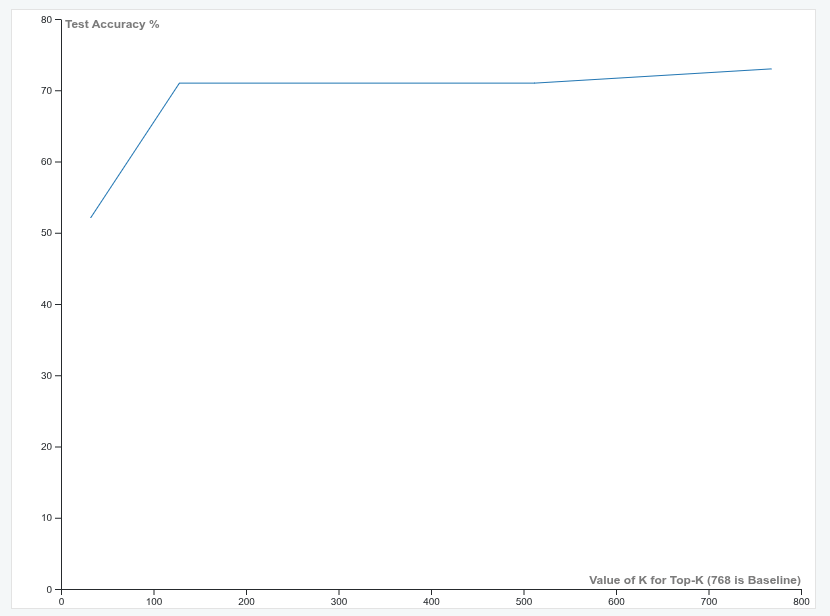

Graph shows an interesting trend, plateau between 128 and 768 preserved vectors from CLIP embedding, but at k=32 accuracy drop significants, this is still a very positive result as k=128 is an 83% reduction in data needed to be sent from clients to server! Further runs will allow us to estimate the correlation of accuracy and value of k better but these results look very promising. (One of our notebook runs ran on CPU despite configurationa dn ended up rning through compute and time which we could have used for better resolution, but we will add more points before next deliverable.)